# Class Notes: Linear Regression, Part 1 (16 June 2026)

Topics covered:
1. What regression analysis is and why we use it
2. Simple linear regression and the best fit line
3. Estimating the coefficients (the math)
4. R squared and adjusted R squared
5. Prediction and plotting the least squares line
6. Model confidence (p values)
7. Multiple linear regression and feature selection
8. Handling categorical predictors

---

In [1]:

# Setup for this notebook
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt


## 1. What is Regression Analysis

Most business questions are really questions about a relationship: if we spend more on TV ads, do sales go up, and by how much. Regression is the tool that answers the "by how much" part.

**Regression analysis is a supervised learning method that models the relationship between a continuous dependent variable (the output we want to predict) and one or more independent variables (the inputs).**

Plainly: we give the model some input columns and one numeric output column, and it learns a formula that turns the inputs into a number.

The word "continuous" is the key divider. Regression predicts a quantity (sales in dollars, temperature, a price). Classification predicts a category (spam or not, disease or no disease). This whole day is about predicting a quantity.

---

## 2. The Use of Regression

Two jobs, and they are different:

- **Prediction**: given a new row of inputs, estimate the output. "This house has these features, what price."
- **Inference**: understand the relationship itself. "How much does each extra 1000 dollars of TV spend move sales, holding radio fixed." Here the coefficients are the answer, not the prediction.

A lot of beginners only think about prediction. In business analytics the inference use is just as common, because a manager wants to know which lever to pull.

---

## 3. Simple Linear Regression

Start with the simplest case: one input, one output.

**Simple linear regression fits a straight line `y = b0 + b1 * x`, where b0 is the intercept and b1 is the slope.**

Plainly: it draws the single straight line that sits closest to all the data points.

```
   y
   |            .
   |         .    <- the fitted line y = b0 + b1*x
   |      . 
   |   .
   | .
   +--------------- x
   b0 is where the line crosses the y axis
   b1 is how much y changes for a one unit rise in x
```

- **b0 (intercept)**: the predicted y when x is 0.
- **b1 (slope, the coefficient)**: how many units y moves for each one unit increase in x. This is the number the inference use cares about.

### How do we know it is the "best" fit line

Any line makes errors. For each point the error is the vertical gap between the real y and the line's prediction, called a **residual**.

**The best fit line is the one that minimizes the sum of squared residuals (the least squares criterion).**

Plainly: square every gap so positives and negatives do not cancel, add them up, and pick the line that makes that total as small as possible.

We square rather than take absolute values for two reasons: it removes the sign, and it punishes big misses much harder than small ones, so the line refuses to sit far from any point.

---

## 4. Estimating the Coefficients (the math)

For simple linear regression the least squares solution has a closed form, no iteration needed:

```
b1 = sum( (x - xbar)(y - ybar) ) / sum( (x - xbar)^2 )
b0 = ybar - b1 * xbar
```

where `xbar` and `ybar` are the means.

Worked example. Hours studied `x = [1,2,3,4,5]`, exam score `y = [52,58,63,72,80]`.

```
xbar = 3, ybar = 65
b1 = 7.0
b0 = 44.0
so the line is:  score = 44 + 7 * hours
```

(Verified in Python.) Reading it back: each extra hour of study adds about 7 points, and a student who studied 0 hours is predicted to score 44.

---

slope     b1 = 7.0
intercept b0 = 44.0
fitted line:  score = 44 + 7 * hours


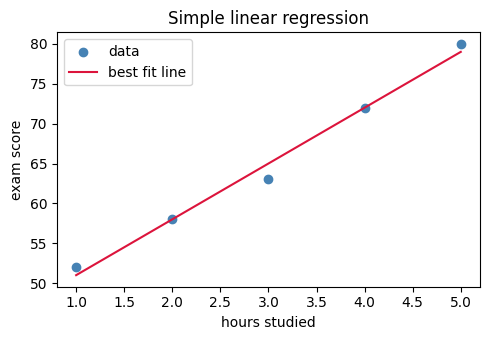

In [2]:
# Simple linear regression, worked by hand on the study-hours example
x = np.array([1, 2, 3, 4, 5], dtype=float)      # hours studied
y = np.array([52, 58, 63, 72, 80], dtype=float) # exam score

xbar, ybar = x.mean(), y.mean()
b1 = np.sum((x - xbar) * (y - ybar)) / np.sum((x - xbar) ** 2)
b0 = ybar - b1 * xbar
print(f"slope     b1 = {b1}")
print(f"intercept b0 = {b0}")
print(f"fitted line:  score = {b0:.0f} + {b1:.0f} * hours")

# plot the points and the least squares line
yhat = b0 + b1 * x
plt.figure(figsize=(5, 3.5))
plt.scatter(x, y, color="steelblue", label="data")
plt.plot(x, yhat, color="crimson", label="best fit line")
plt.xlabel("hours studied"); plt.ylabel("exam score")
plt.title("Simple linear regression"); plt.legend(); plt.tight_layout()
plt.show()

## 5. R squared and Adjusted R squared

A line always fits something, so we need a score for how good the fit actually is.

**R squared is the proportion of the variance in y that the model explains, on a 0 to 1 scale.**

Plainly: 0 means the line is useless (no better than just guessing the average of y every time), 1 means the line passes through every point perfectly.

```
R^2 = 1 - SS_res / SS_tot

SS_res = sum( (y - yhat)^2 )     the error the model still has
SS_tot = sum( (y - ybar)^2 )     the error if you always guessed the mean
```

Using the study example above: `SS_res = 6.0`, `SS_tot = 496.0`, so `R^2 = 0.9879`. (Verified in Python.) The line explains about 98.8 percent of the variation in scores.

### The problem R squared has

R squared can only go up or stay flat when you add a new input column, even a useless random one. So it will happily reward you for junk features. That is why we need a corrected version.

**Adjusted R squared penalizes R squared for every extra predictor, so it only rises when the new feature earns its keep.**

```
Adjusted R^2 = 1 - (1 - R^2) * (n - 1) / (n - p - 1)

n = number of rows, p = number of predictors
```

For the study example (n=5, p=1): `Adjusted R^2 = 0.9839`, slightly below the raw 0.9879. (Verified in Python.) Rule of thumb: when comparing models with different numbers of features, trust adjusted R squared, not R squared.

---

In [3]:
# R^2 and adjusted R^2 for the fitted line
ss_res = np.sum((y - yhat) ** 2)   # error the model still makes
ss_tot = np.sum((y - ybar) ** 2)   # error of always guessing the mean
r2 = 1 - ss_res / ss_tot

n, p = len(x), 1                   # rows, predictors
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"SS_res = {ss_res:.2f}")
print(f"SS_tot = {ss_tot:.2f}")
print(f"R^2          = {r2:.4f}")
print(f"Adjusted R^2 = {adj_r2:.4f}")

SS_res = 6.00
SS_tot = 496.00
R^2          = 0.9879
Adjusted R^2 = 0.9839


## 6. Prediction and Plotting the Line

Once the coefficients are learned, prediction is just plugging in:

```
new student studies 6 hours
score = 44 + 7 * 6 = 86
```

To draw the fitted line you do not need every point. Predict y at just the smallest and largest x, then connect those two predictions with a straight line, because a line is fully defined by two points.

---

In [4]:
# predict the score for a student who studies 6 hours
hours = 6
pred = b0 + b1 * hours
print(f"predicted score for {hours} hours = {pred:.0f}")

predicted score for 6 hours = 86


## 7. Model Confidence (p values)

A coefficient can look non zero just by luck of the sample. We need a significance test.

**The p value for a coefficient is the probability of seeing a relationship this strong by pure chance if the true coefficient were actually zero.**

Plainly: a small p value means "this feature really does matter," a large one means "this feature might be noise."

The common cutoff is 0.05. If a predictor's p value is below 0.05 we keep it, if it is well above we suspect it adds nothing. This is the formal version of feature selection.

---

## 8. Multiple Linear Regression

Real problems have several inputs, so we extend the line into a plane (and beyond).

**Multiple linear regression fits `y = b0 + b1*x1 + b2*x2 + ... + bn*xn`, one coefficient per input feature.**

Plainly: same idea as the single line, but now each feature gets its own slope, and each slope is read as "the effect of this feature while holding all the others fixed."

That "holding the others fixed" part is what makes multiple regression useful for inference. If TV and radio both drive sales, the TV coefficient tells you TV's effect after radio is already accounted for.

### Feature Selection

Not every column helps. The workflow is to compare models:

- Fit with all features, look at each p value.
- Drop features with high p values (the ones that look like noise).
- Watch adjusted R squared. If it goes up after dropping a feature, that feature was hurting you.

A classic example: adding a "newspaper" spend column that has no real link to sales will barely move R squared and will lower adjusted R squared, which is the signal to drop it.

---

In [5]:
# multiple linear regression with scikit-learn on a small advertising-style table
import pandas as pd
from sklearn.linear_model import LinearRegression

data = pd.DataFrame({
    "tv":        [230, 44,  17, 151, 180, 8,  57, 120],
    "radio":     [37,  39,  45, 41,  10,  2,  24, 20],
    "newspaper": [69,  45,  69, 58,  8,   1,  13, 30],   # suspected noise feature
    "sales":     [22,  10,  9,  18,  13,  4,  12, 15],
})
X = data[["tv", "radio", "newspaper"]]
y_sales = data["sales"]

model = LinearRegression().fit(X, y_sales)
for name, coef in zip(X.columns, model.coef_):
    print(f"{name:10} coefficient = {coef:+.4f}")
print(f"intercept            = {model.intercept_:.4f}")
print(f"R^2 on training data = {model.score(X, y_sales):.4f}")
print("\nnewspaper has the smallest effect, the first candidate to drop in feature selection")

tv         coefficient = +0.0604
radio      coefficient = +0.1707
newspaper  coefficient = -0.0274
intercept            = 3.1389
R^2 on training data = 0.9264

newspaper has the smallest effect, the first candidate to drop in feature selection


## 9. Handling Categorical Predictors

Regression needs numbers, but many columns are categories (small/large, region A/B/C). We convert them.

**A dummy variable is a 0/1 column that encodes membership in a category.**

### Two categories

For a yes/no style feature like size, make one column `IsLarge` that is 1 for large and 0 for small. The coefficient on `IsLarge` then reads as "how much y differs for large versus small."

### More than two categories

For a feature with three groups (say A, B, C) you create dummy columns with `get_dummies`, then drop the first one:

```
group A -> [0, 0]   (this is the baseline, both dummies 0)
group B -> [1, 0]
group C -> [0, 1]
```

**We always drop one dummy to avoid the dummy variable trap.**

Plainly: if you kept a column for every category, they would add up to a constant and perfectly overlap with the intercept, which breaks the math. Dropping one makes that category the baseline, and every other coefficient is read relative to it.

This "one category overlaps with others" idea is exactly the multicollinearity problem, which is where Part 2 (17 June) picks up.

In [6]:
# turning a categorical column into dummy variables, dropping one to avoid the trap
import pandas as pd
df = pd.DataFrame({"size": ["small", "large", "medium", "large", "small"]})
dummies = pd.get_dummies(df["size"], drop_first=True).astype(int)
print(pd.concat([df, dummies], axis=1).to_string(index=False))
print("\n'large' is the dropped baseline; each kept column is read relative to it")

  size  medium  small
 small       0      1
 large       0      0
medium       1      0
 large       0      0
 small       0      1

'large' is the dropped baseline; each kept column is read relative to it
